# **IEEE SB - alrIEEEna26 ML Challenge**
**Team Name : HashMap (G110/1)**

# **Setup & Dataset Import**

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NOTE: Add Input Dataset [alrieeena26-ml-challenge-by-ieee-sb-gehu] Before Use.

# Path Defination
base_path = '/kaggle/input/datasets/ieeesbgehu/alrieeena26-ml-challenge-by-ieee-sb-gehu/ML FINAL DATASET/'
train_csv_path = os.path.join(base_path, 'TRAIN.csv')
test_csv_path = os.path.join(base_path, 'TEST.csv')
image_dir = os.path.join(base_path, 'images/')

In [4]:
# Verify CSVs Sucessfully Imported 
try:
    test_df = pd.read_csv(test_csv_path)
    train_df = pd.read_csv(train_csv_path)
    print("✅ TRAIN.CSV and TEST.CSV loaded successfully!")
except Exception as e:
    print("❌ Error loading CSVs:", e)

✅ TRAIN.CSV and TEST.CSV loaded successfully!


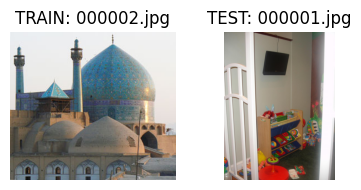

In [5]:
# Sample Images to Verify Images Sucessfully Imported 
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

train_img_path = os.path.join(image_dir, train_df['IMAGE'].iloc[0])
sample_train_img = plt.imread(train_img_path)
axes[0].imshow(sample_train_img)
axes[0].set_title(f"TRAIN: {train_df['IMAGE'].iloc[0]}")
axes[0].axis("off")

test_img_path = os.path.join(image_dir, test_df['IMAGE'].iloc[0])
sample_test_img = plt.imread(test_img_path)
axes[1].imshow(sample_test_img)
axes[1].set_title(f"TEST: {test_df['IMAGE'].iloc[0]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
# ========================
# LOAD DATA
# ========================
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

# FIX LABELS (already numeric)
train_df['label'] = train_df['LABEL'].astype(int)

num_classes = train_df['label'].nunique()
print("Classes:", num_classes)

Classes: 397


In [12]:
# ========================
# TRAIN / VAL SPLIT
# ========================
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['label'],
    random_state=42
)

In [13]:
# ========================
# AUGMENTATION
# ========================
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [14]:
# ========================
# DATASET
# ========================
from torch.utils.data import Dataset
from PIL import Image

class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['IMAGE']   # FIXED
        label = self.df.iloc[idx]['label']

        path = os.path.join(self.img_dir, img_name)
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
# ========================
# MODEL
# ========================
import timm
import torch
import torch.nn as nn

model = timm.create_model('efficientnet_b2', pretrained=True)

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)

model = model.cuda()

In [16]:
# ========================
# LOSS + OPTIMIZER
# ========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [17]:
# ========================
# MIXUP
# ========================
import numpy as np

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).cuda()

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [27]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    ImageDataset(train_df, image_dir, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    ImageDataset(val_df, image_dir, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train loader ready:", len(train_loader))

Train loader ready: 1049


In [28]:
scaler = torch.amp.GradScaler('cuda')

for images, labels in train_loader:
    images = images.cuda()
    labels = labels.cuda()

    optimizer.zero_grad()

    with torch.amp.autocast(device_type='cuda'):
        outputs = model(images)
        loss = criterion(outputs, labels)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

In [29]:
from tqdm import tqdm

EPOCHS = 10
best_acc = 0

scaler = torch.amp.GradScaler('cuda')

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # ================= TRAIN =================
    model.train()
    train_loss = 0

    loop = tqdm(train_loader)

    for images, labels in loop:
        images = images.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    scheduler.step()

    # ================= VALIDATION =================
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            labels = labels.cuda()

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Validation Accuracy: {acc:.4f}")

    # ================= SAVE BEST MODEL =================
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "effnet_b2_best.pth")
        print("Model Saved 🔥")


Epoch 1/10


100%|██████████| 1049/1049 [06:14<00:00,  2.80it/s, loss=2.1] 


Validation Accuracy: 0.6090
Model Saved 🔥

Epoch 2/10


100%|██████████| 1049/1049 [06:17<00:00,  2.78it/s, loss=1.69]


Validation Accuracy: 0.6165
Model Saved 🔥

Epoch 3/10


...

Validation Accuracy: 0.6581
Model Saved 🔥

Epoch 9/10


100%|██████████| 1049/1049 [06:04<00:00,  2.88it/s, loss=1]    


Validation Accuracy: 0.6586
Model Saved 🔥

Epoch 10/10


100%|██████████| 1049/1049 [06:13<00:00,  2.81it/s, loss=1.02] 


Validation Accuracy: 0.6629
Model Saved 🔥


In [32]:
model.load_state_dict(torch.load("effnet_b2_best.pth"))

<All keys matched successfully>

In [34]:
# =========================
# TEST DATASET
# =========================
class TestDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['IMAGE']
        path = os.path.join(self.img_dir, img_name)

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name


# =========================
# TEST LOADER
# =========================
test_loader = DataLoader(
    TestDataset(test_df, image_dir, val_transform),
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


# =========================
# LOAD BEST MODEL (FIXED NAME)
# =========================
model.load_state_dict(torch.load("effnet_b2_best.pth", map_location='cuda'))
model.eval()


# =========================
# INFERENCE
# =========================
predictions = []
image_names = []

with torch.no_grad():
    for images, names in test_loader:
        images = images.cuda()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        image_names.extend(names)


# =========================
# SAVE FINAL.csv
# =========================
final_df = pd.DataFrame({
    'IMAGE': image_names,
    'LABEL': predictions
})

final_df.to_csv("FINAL.csv", index=False)

print("FINAL.csv saved successfully 🚀")

FINAL.csv saved successfully 🚀


In [42]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomRotation(10),
    transforms.RandomErasing(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,
    T_mult=2
)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

In [44]:
from tqdm import tqdm

EPOCHS = 15
best_acc = 0

scaler = torch.amp.GradScaler('cuda')

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    correct, total = 0, 0

    for images, labels in tqdm(train_loader):
        images, labels = images.cuda(), labels.cuda()

        # 🔥 MIXUP
        images, y_a, y_b, lam = mixup_data(images, labels)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = mixup_loss(criterion, outputs, y_a, y_b, lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        # 🔥 Approx accuracy for mixup
        preds = outputs.argmax(1)
        correct += (lam * (preds == y_a).sum().item() +
                    (1 - lam) * (preds == y_b).sum().item())
        total += labels.size(0)

    train_acc = correct / total
    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"""
Epoch {epoch+1}
Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}
Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}
""")

    # ===== SAVE BEST =====
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

100%|██████████| 1049/1049 [06:21<00:00,  2.75it/s]



Epoch 1
Train Loss: 1922.7540 | Train Acc: 0.8442
Val Loss:   272.7670 | Val Acc:   0.6315



 10%|█         | 110/1049 [00:42<05:59,  2.61it/s]


KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm
import torch

# ===== LOAD OLD MODEL =====
model.load_state_dict(torch.load("effnet_b2_best.pth"))  # change if different name

# ===== SETTINGS =====
EPOCHS = 10   # short fine-tuning
best_acc = 0

scaler = torch.amp.GradScaler('cuda')

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    correct, total = 0, 0

    for images, labels in tqdm(train_loader):
        images, labels = images.cuda(), labels.cuda()

        # 🔥 MIXUP
        images, y_a, y_b, lam = mixup_data(images, labels)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = mixup_loss(criterion, outputs, y_a, y_b, lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        # Approx train accuracy (mixup)
        preds = outputs.argmax(1)
        correct += (lam * (preds == y_a).sum().item() +
                    (1 - lam) * (preds == y_b).sum().item())
        total += labels.size(0)

    train_acc = correct / total
    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"""
Epoch {epoch+1}
Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}
Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}
""")

    # ===== SAVE BEST =====
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model_finetuned.pth")

100%|██████████| 1049/1049 [06:22<00:00,  2.75it/s]



Epoch 1
Train Loss: 1970.5126 | Train Acc: 0.8362
Val Loss:   276.0384 | Val Acc:   0.6256



 61%|██████    | 635/1049 [03:50<01:53,  3.63it/s]

In [ ]:
def tta_val(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.cuda(), labels.cuda()

            out1 = model(images)

            flipped = torch.flip(images, dims=[3])
            out2 = model(flipped)

            outputs = (out1 + out2) / 2
            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

print("TTA Accuracy:", tta_val(model, val_loader))

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()

        images, y_a, y_b, lam = mixup_data(images, labels)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = mixup_loss(criterion, outputs, y_a, y_b, lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# **Implementation & Training**

In [6]:
# Implement EDA, Visualizations, Training & Explanations 

In [1]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
import timm
import torch.nn as nn

model = timm.create_model('efficientnet_b2', pretrained=True)

# Replace head
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 397)

model = model.cuda()

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=10
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_55/260589822.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [6]:
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).cuda()

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# **Generating Predections & FINAL.csv**

In [7]:
# Use Trained Model to Generate Predections on TEST.csv 

# Example of Output .CSV
#-----------------------
# IMAGE         LABLE
# 000001.jpg	   1
# 000003.jpg	   3
# 000013.jpg	   26
# 000017.jpg	   6
#------------------------

#@ Follow Above Exact format for output file 
#@ Name file exactly FINAL.csv and Columns as IMAGE and LABLE

# **Notebook Submission for [@alrIEEEna26 2026](https://www.linkedin.com/posts/ieeesb-gehu_alrieeena26-ieee-machinelearning-activity-7434653027216764928-AwEY)**
## **Organised by [IEEE SB GEHU Dehradun](https://linktr.ee/IEEE_SB_GEHU)**